In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
from functions import dL_rosenbrock_1d
from src.optimizer import AdamScratch1D, NonlocalSolverMomentumAdam
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np

# CONDITIONS

In [ ]:
a = 1
lr = 0.001
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
epochs = int(1e4)
initial_theta = 5.0

# DISCRETE-ADAM

In [ ]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(a,)
    )

print(f"Valor final de theta: {theta_history[-1]}")


TypeError: cannot unpack non-iterable int object

/home/thebigmonster/Github/nonlocal-adam-type/src/utils/ploting.py:105: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1, 1].set_yscale('log')


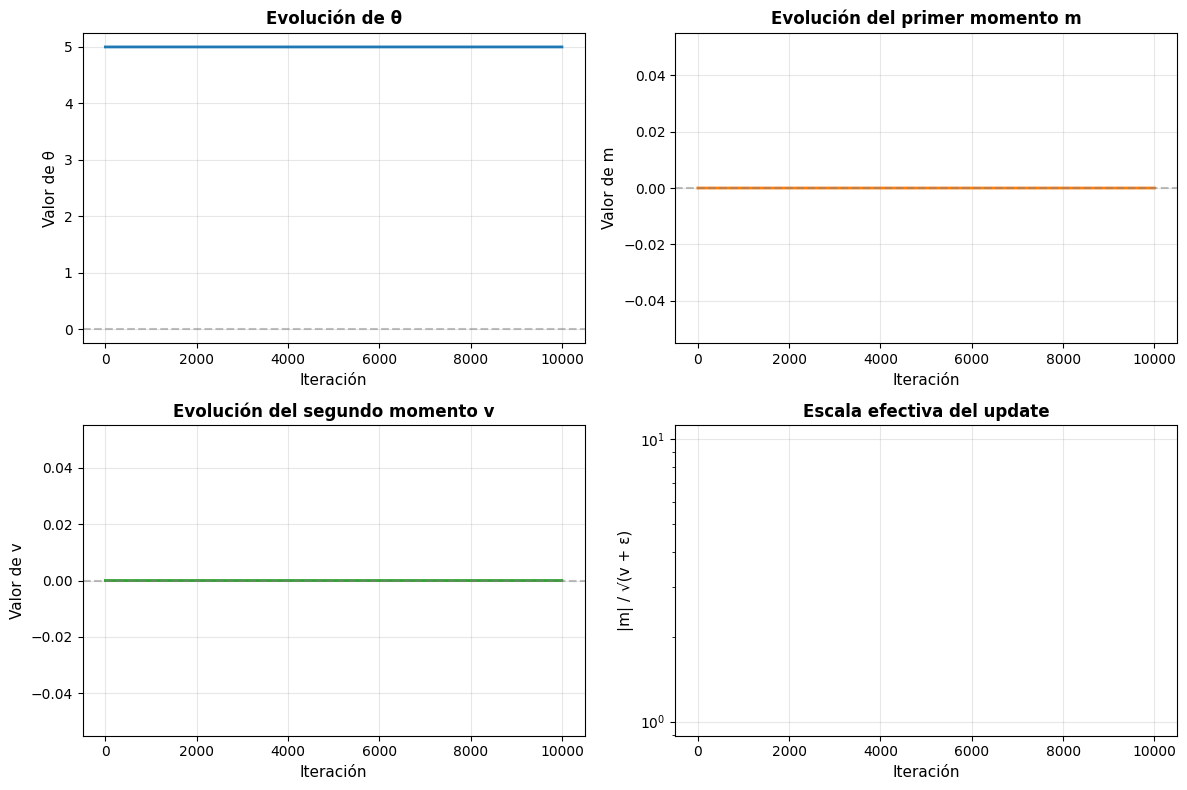

In [5]:
# Crear el plotter y visualizar
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plotear todo
plotter.plot('all')
plt.show()

# CONTINUOUS ADAM

In [6]:
def dL_wrapper(theta):
    return dL_quadratic((lambda1, lambda2), theta)

In [7]:
print("Resolviendo theta1...")
optimizer_theta1 = NonlocalSolverMomentumAdam(
    dL=lambda theta: lambda1 * theta,  # Gradiente solo de theta1
    t_span=(1e-6, 10.0),
    y0=[5.0, 0],  # Condición inicial para theta1
    alpha=0.001,
    betas=(0.9, 0.999),
    eps_base=1e-8,
    verbose=True,
    quad_order=50
)
t1, theta1_history = optimizer_theta1.solve()

# Resolver theta2 (segunda componente)
print("Resolviendo theta2...")
optimizer_theta2 = NonlocalSolverMomentumAdam(
    dL=lambda theta: lambda2 * theta,  # Gradiente solo de theta2
    t_span=(1e-6, 10.0),
    y0=[-5.0, 0],  # Condición inicial para theta2
    alpha=0.001,
    betas=(0.9, 0.999),
    eps_base=1e-8,
    verbose=True,
    quad_order=50
)
t2, theta2_history = optimizer_theta2.solve()

# Combinar resultados
theta_history = np.column_stack([theta1_history, theta2_history])

print(f"\nValor final de theta: [{theta1_history[-1]:.6e}, {theta2_history[-1]:.6e}]")
print(f"Tiempo final: {t1[-1]}")
print(f"Número de pasos: {len(t1)}")

Resolviendo theta1...
Second order equation --> using sinh/sin kernels
ParallelComputation: joblib backend='loky', workers=23/24

Building functional RHS (iteration 0)...
¿NaNs in y?: False
Computing moments for 10000 time points...
  Parallel execution: 10000 items → 23 workers (joblib/loky)


/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/tools/kernels_definition.py:23: RuntimeWarning: overflow encountered in sinh
  return (2.0 / kappa) * np.exp(-s / alpha) * np.sinh((kappa / alpha) * s)
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/tools/kernels_definition.py:23: RuntimeWarning: overflow encountered in sinh
  return (2.0 / kappa) * np.exp(-s / alpha) * np.sinh((kappa / alpha) * s)
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/tools/kernels_definition.py:23: RuntimeWarning: overflow encountered in sinh
  return (2.0 / kappa) * np.exp(-s / alpha) * np.sinh((kappa / alpha) * s)
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/tools/kernels_definition.py:23: RuntimeWarning: overflow encountered in sinh
  return (2.0 / kappa) * np.exp(-s / alpha) * np.sinh((kappa / alpha) * s)
/home/thebigmonster/Github/nonlocal-adam-type/src/optimizer/tools/kernels_definition.py:23: RuntimeWarning: overflow encountered in sinh
  return (2.0 /

KeyboardInterrupt: 